#### On the basis of the categories, Logistic Regression can be classified into three types:

##### Binomial: 
    ----> In binomial Logistic regression, there can be only two possible types of the dependent variables, such as 0 or 1, Pass or Fail, etc.

##### Multinomial: 
    ----> In multinomial Logistic regression, there can be 3 or more possible unordered types of the dependent variable, such as "cat", "dogs", or "sheep".

##### Ordinal: 
    ----> In ordinal Logistic regression, there can be 3 or more possible ordered types of dependent variables, such as "low", "Medium", or "High".

## Binary Classification Binomial Input:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv("data/placement.csv")

In [4]:
dataset.head()

,cgpa,score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


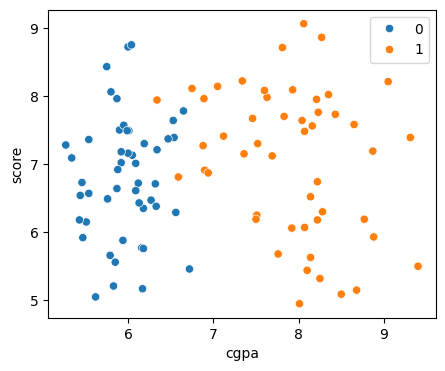

In [5]:
plt.figure(figsize=(5,4))
sns.scatterplot(x="cgpa", y="score", data=dataset, hue="placed")
plt.legend(loc=1)
plt.show()

In [6]:
x = dataset.iloc[:,:-1]
y = dataset["placed"]

In [7]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cgpa    100 non-null    float64
 1   score   100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LogisticRegression

In [11]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)

1.0

In [12]:
lr.coef_, lr.intercept_

(array([[3.03417823, 0.49690768]]), array([-24.13435286]))

In [13]:
from mlxtend.plotting import plot_decision_regions

c:\Users\taksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


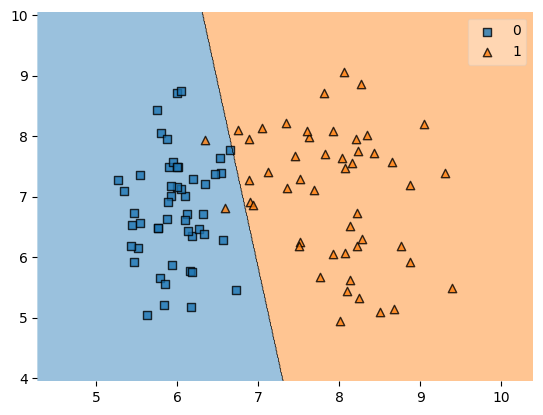

In [14]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), lr)
plt.show()

## Binomial Classification Polynomial Input

#### Trying without polynomial feature

In [15]:
dataset = pd.read_csv("data/binary.csv")

In [16]:
dataset.head()

,f1,f2,op
0,-8,2,1
1,1,1,0
2,-5,-9,1
3,2,-2,0
4,7,4,1


In [17]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   f1      207 non-null    int64
 1   f2      207 non-null    int64
 2   op      207 non-null    int64
dtypes: int64(3)
memory usage: 5.0 KB


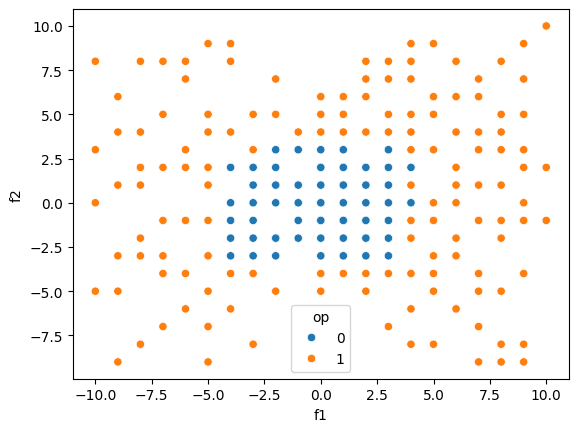

In [18]:
sns.scatterplot(x="f1", y="f2", data=dataset, hue="op")
plt.show()

In [19]:
x = dataset.iloc[:,:-1]
y = dataset["op"]

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [21]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)

0.5961538461538461

c:\Users\taksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


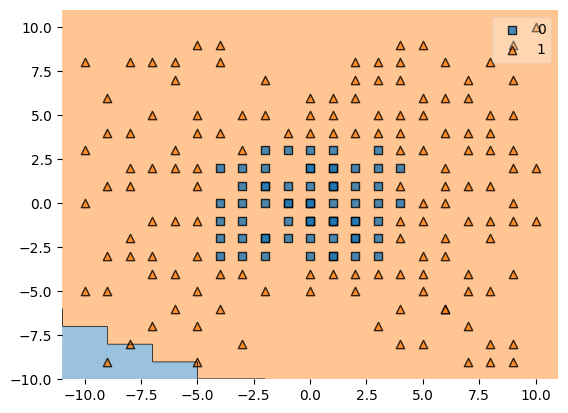

In [22]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), lr)
plt.show()

### trying with polynomial feature

In [23]:
dataset = pd.read_csv("data/binary.csv")

In [24]:
dataset.head()

,f1,f2,op
0,-8,2,1
1,1,1,0
2,-5,-9,1
3,2,-2,0
4,7,4,1


In [25]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   f1      207 non-null    int64
 1   f2      207 non-null    int64
 2   op      207 non-null    int64
dtypes: int64(3)
memory usage: 5.0 KB


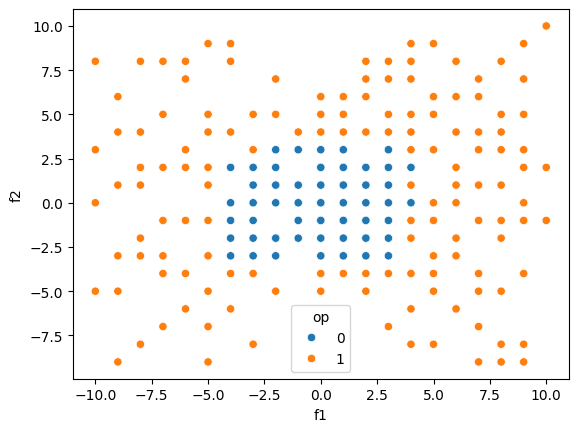

In [26]:
sns.scatterplot(x="f1", y="f2", data=dataset, hue="op")
plt.show()

In [90]:
x = dataset.iloc[:,:-1]
y = dataset["op"]

In [91]:
from sklearn.preprocessing import PolynomialFeatures

In [92]:
pf = PolynomialFeatures(degree=2)
pf.fit(x)
x_poly = pf.transform(x)

In [93]:
new_columns = pf.get_feature_names_out(x.columns)
new_columns

array(['1', 'f1', 'f2', 'f1^2', 'f1 f2', 'f2^2'], dtype=object)

In [94]:
x = pd.DataFrame(x_poly, columns=new_columns)

In [95]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [96]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)

0.9807692307692307

## Multiclass classification


In [97]:
dataset = pd.read_csv('data/iris.csv')

In [98]:
dataset.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [100]:
dataset.drop(columns=["Id"], inplace=True)

In [102]:
dataset["Species"].unique()

<ArrowStringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

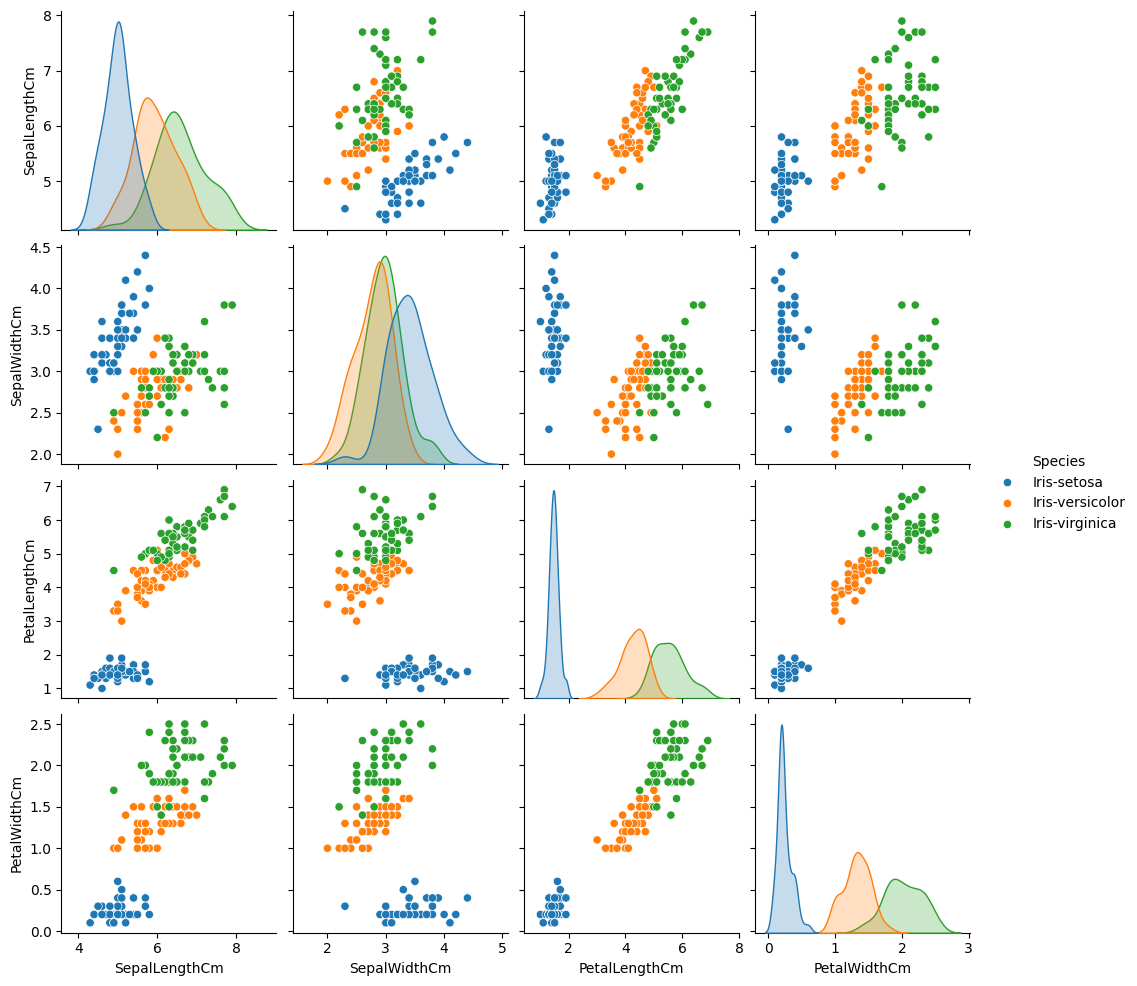

In [103]:
sns.pairplot(data=dataset, hue="Species")
plt.show()

In [104]:
x = dataset.iloc[:,:-1]
y = dataset["Species"]

In [105]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

#### In sklearn recent versions, the feature multi_class is now choosing the type automatically based on the data that is being fit to the model such 'ovr', 'multinomial', 'auto'. so now it won't accept parameter named 'model_class' but will choose the most suitable class

In [116]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)

1.0